# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you would be able to present to future employers. One is a brief one-page summary of this project that you would present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Please consider your prior course work and select one way to achieve this given project question. Either use a regression model or machine learning model to predict whether or not an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


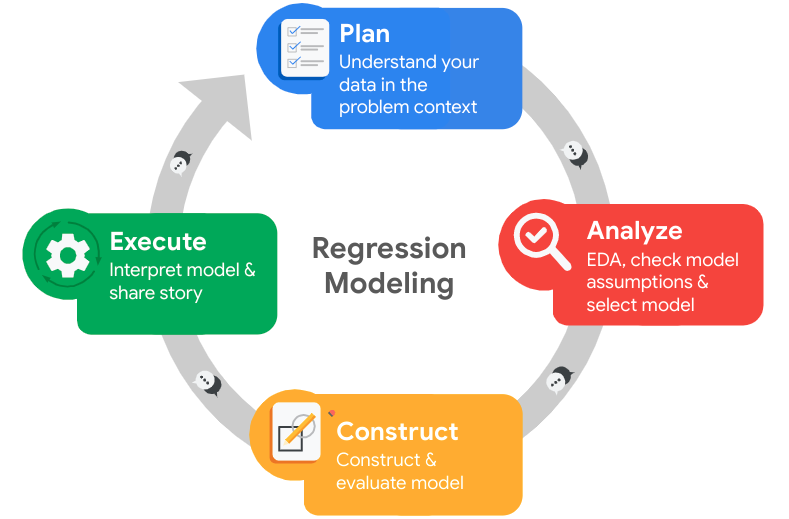

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




### **Plan Stage Reflection**  
**Who are your stakeholders for this project?**
The primary stakeholders are:  
- **HR Department at Salifort Motors** – They need data-driven insights to improve employee satisfaction and retention.  
- **Company Leadership/Management** – Decision-makers who will implement retention strategies.  
- **Employees** – Their job satisfaction and work conditions may be directly affected by the insights and recommendations.  

**What are you trying to solve or accomplish?**  
- Identify key factors influencing employee attrition.  
- Build a predictive model to forecast whether an employee is likely to leave.  
- Provide actionable recommendations to improve employee retention and satisfaction.  
- Help HR reduce turnover costs by implementing data-driven strategies.  

**What are your initial observations when you explore the data?**  
- **Job satisfaction and last evaluation scores** could be strong indicators of employee retention.  
- **Work hours and project load** may contribute to burnout and attrition.  
- **Longer tenure without promotion** could lead to dissatisfaction.  
- **Salary levels** might influence employee decisions to leave.  
- **Work accidents** may also impact employee satisfaction and retention.  

**What resources do you find yourself using as you complete this stage?**  
- **Kaggle Dataset** – For dataset structure and metadata.  
- **Pandas & NumPy** – For initial data exploration and preprocessing.  
- **Matplotlib & Seaborn** – For visualizing trends in employee satisfaction and attrition.  
- **Scikit-learn** – For building and evaluating predictive models.  

**ethical considerations**  
- **Bias in Data** – Ensure the model does not reinforce discrimination based on department, salary, or promotions.  
- **Privacy Concerns** – Handle employee data responsibly, ensuring anonymity and compliance with data protection laws.  
- **Fairness in Decision-Making** – Recommendations should support fair policies rather than penalize employees based on predictions.  


## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 

# EDA & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Modeling
# For metrics and helpful functions
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV



### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [7]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
#df = pd.read_csv(r"/Users/derrick/Downloads/HR_comma_sep.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [9]:
# Gather basic information about the data
### YOUR CODE HERE ###
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [10]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [11]:
# Display all column names
### YOUR CODE HERE ###
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [13]:
# Rename columns as needed
### YOUR CODE HERE ###
df.rename(columns={'number_project':'number_of_projects',
    'time_spend_company':'tenure',
    'average_montly_hours':'average_monthly_hours',
    'Work_accident':'work_accident',
    'Department': 'department'}, inplace=True)

# Display all column names after the update
### YOUR CODE HERE ###
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_of_projects',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [14]:
# Check for missing values
### YOUR CODE HERE ###
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_of_projects       0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

***Data contains no missing values***

### Check duplicates

Check for any duplicate entries in the data.

In [15]:
# Check for duplicates
### YOUR CODE HERE ###
df.duplicated().sum()

3008

In [16]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
duplicates = df[df.duplicated()]
duplicates.head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [17]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df.drop_duplicates()

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()


,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

Text(0.5, 0, 'Years with the Company')

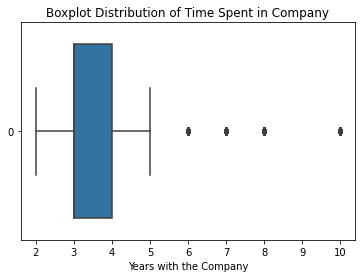

In [18]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
### YOUR CODE HERE ###

sns.boxplot(data = df1['tenure'], orient = 'h')
plt.title('Boxplot Distribution of Time Spent in Company')
plt.xlabel('Years with the Company')

The boxplot shows that there are outliers in the Tenure column: we will use the method of quartiles to find the count of outliers

In [19]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###

Q1 = df1['tenure'].quantile(0.25)
Q3 = df1['tenure'].quantile(0.75)
IQR = Q3 - Q1

#Define the outlier bounds
lower_bound = Q1 - (0.25* IQR)
upper_bound = Q3 + (0.75* IQR)

#Identify rows with outliers
outliers = df1[(df1['tenure'] < lower_bound) | 
              (df1['tenure'] > upper_bound)]

#Count these rows containing outliers
outlier_row_count = outliers.shape[0]
outlier_row_count

4796

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [20]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
left_vrs_stayed = df1['left'].value_counts().rename({0:'stayed', 1:'left'})

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
left_vrs_stayed_percentage = df1['left'].value_counts(normalize = True)* 100

print(left_vrs_stayed)
print(left_vrs_stayed_percentage)



stayed    10000
left       1991
Name: left, dtype: int64
0    83.39588
1    16.60412
Name: left, dtype: float64


In [21]:
df1.describe()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

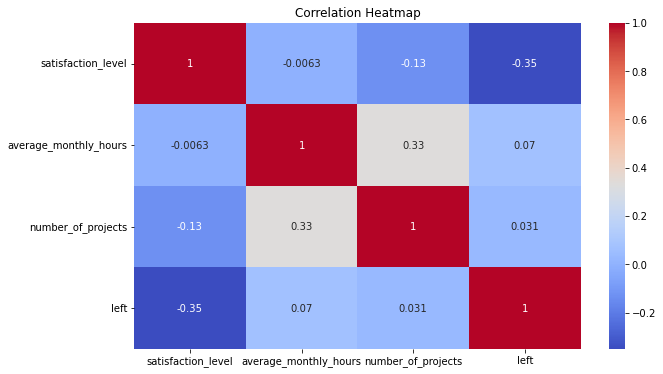

In [22]:
# Create a plot as needed
### YOUR CODE HERE ###

correlation_matrix = df1[['satisfaction_level', 'average_monthly_hours', 
                          'number_of_projects', 'left']].corr()


# create a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, cmap = 'coolwarm', annot = True)
plt.title('Correlation Heatmap')
plt.show()

### **Key Observations from the Heatmap:**  
1. **Satisfaction Level & Turnover (`left`)** → **Strong Negative Correlation (-0.35)**  
   - Employees with **lower satisfaction levels** are more likely to leave.  
   - This suggests that improving employee satisfaction could help reduce attrition.  

2. **Average Monthly Hours & Turnover (`left`)** → **Weak Positive Correlation (0.07)**  
   - There is a very slight positive relationship between working hours and leaving the company.  
   - This suggests that **working longer hours alone is not a strong factor** in turnover.  
   - However, a **non-linear effect** may exist, which a scatterplot could reveal.  

3. **Number of Projects & Turnover (`left`)** → **Very Weak Positive Correlation (0.031)**  
   - The number of projects doesn’t seem to have a significant impact on turnover.  
   - However, it may interact with other variables, such as working hours or satisfaction.  

4. **Average Monthly Hours & Number of Projects** → **Moderate Positive Correlation (0.33)**  
   - Employees with more projects tend to work more hours.  
   - This is expected, as more responsibilities generally require more time.  

---

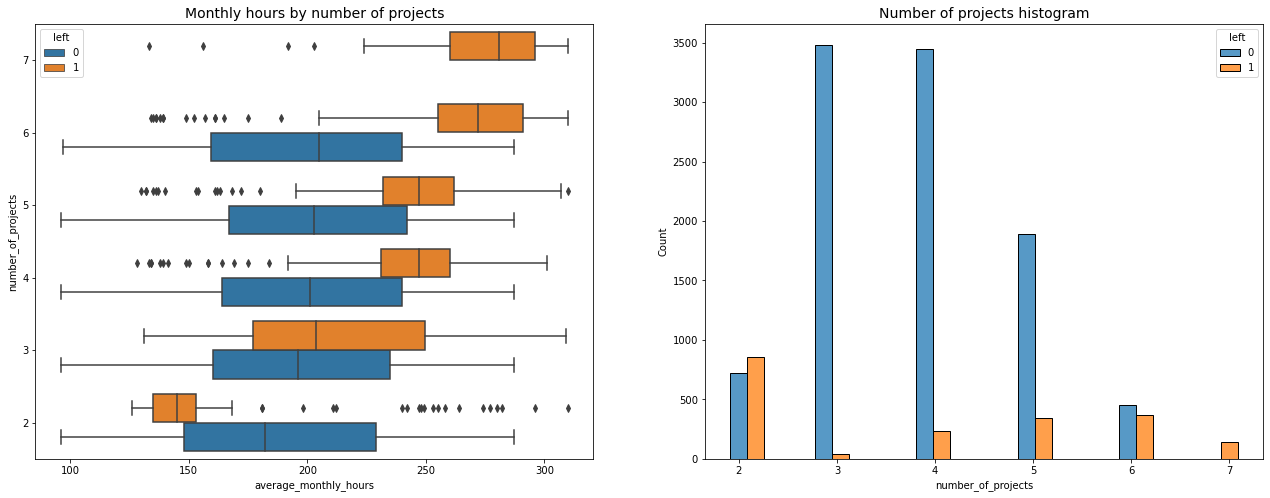

In [23]:
# Create a plot as needed 
### YOUR CODE HERE ###

# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_of_projects', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_of_projects']
tenure_left = df1[df1['left']==1]['number_of_projects']
sns.histplot(data=df1, x='number_of_projects', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

# Display the plots
plt.show()

### General Observations  
- Employees working on more projects tend to work longer hours.  
- The mean hours worked increases with the number of projects.  

### Groups of Employees Who Left  
1. **Group A: Those who worked considerably less than their peers with the same number of projects.**  
   - Possible reasons:  
     - They were fired.  
     - They had already given notice and were assigned fewer hours before leaving.  

2. **Group B: Those who worked much more than their peers.**  
   - Possible reason:  
     - They likely quit due to being overworked.  
   - Employees in this group might have been major contributors to their projects.  
 
- **All employees with seven projects left the company.**  
- **Employees with six or seven projects worked significantly more hours (~255–295 hours/month).**  
- **Optimal workload appears to be 3–4 projects.**  
  - The ratio of employees who left vs. those who stayed is very low in this cohort.  
- **Employees across all project levels (except those with two projects) worked more than a standard 40-hour workweek.**  
  - A standard workweek (40 hours, two weeks vacation) equals **~167 hours per month**.  
  - Most employees worked well above this, indicating overwork.  



In [24]:
df1[df1['number_of_projects']==7]['left'].value_counts() # employees with seven projects indeed left the company.

1    145
Name: left, dtype: int64

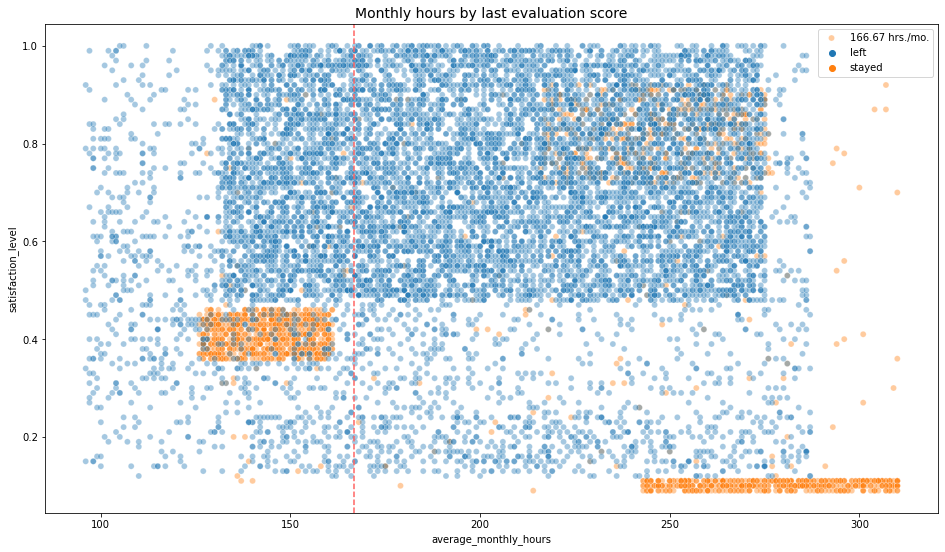

In [25]:
# Create a plot as needed
### YOUR CODE HERE ###
# Create scatterplot of `average_monthly_hours` versus `satisfaction_level`, 
# comparing employees who stayed versus those who left

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

 ### **Observations from the Scatterplot**  
- **High-Workload Group (~240–315 hours/month)**  
  - Some employees worked extreme hours, exceeding **75 hours per week** for an entire year.  
  - Their **satisfaction levels were close to zero**, likely due to overwork.  

- **Normal-Workload Group (~160–210 hours/month) Who Still Left**  
  - Despite having reasonable working hours, their **satisfaction was around 0.4**.  
  - Possible reasons for leaving:  
    - **Workplace pressure** due to peers working significantly more.  
    - **Lowered job satisfaction** due to cultural or management factors.  

- **High-Satisfaction Group (~210–280 hours/month)**  
  - Employees in this range had **satisfaction levels between 0.7 and 0.9**.  
  - Despite working longer hours, they were relatively satisfied.  

### **Data Anomalies**  
- The **distribution shapes appear unusual**, suggesting possible **data manipulation or synthetic data**.  


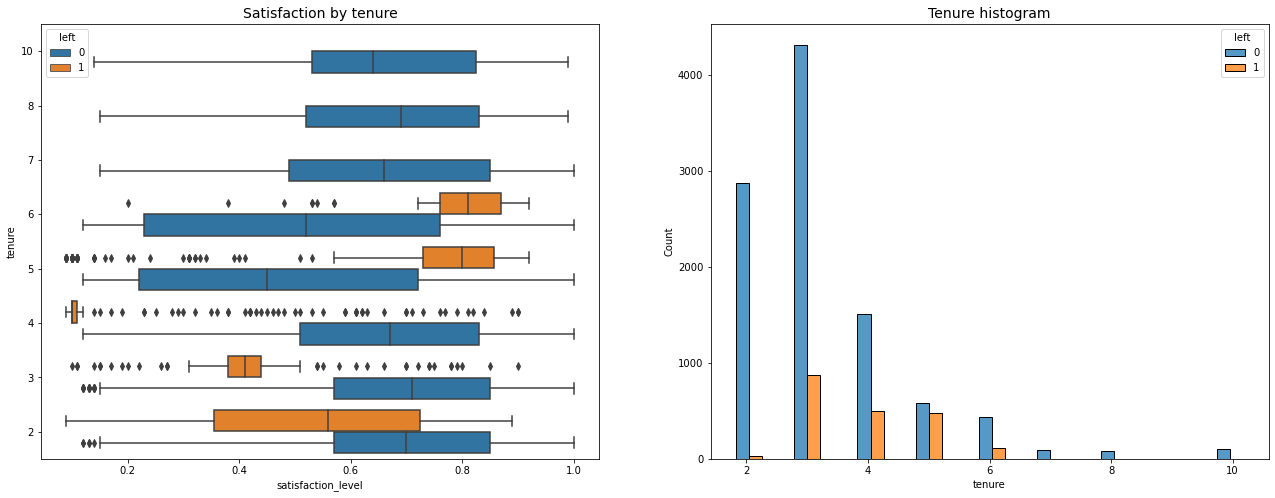

In [26]:
# Create a plot as needed
### YOUR CODE HERE ###

# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

### **Observations from the Plot**  

- **Two Main Groups of Employees Who Left:**  
  1. **Dissatisfied employees with shorter tenures.**  
  2. **Very satisfied employees with medium-length tenures.**  

- **Notable Trend at the Four-Year Mark:**  
  - Employees with **four years of tenure had unusually low satisfaction levels**.  
  - Possible explanation:  
    - A **policy change** may have impacted employees specifically at this stage.  

- **Long-Tenured Employees Stayed:**  
  - Their **satisfaction levels were similar to newer employees who stayed**.  
  - The histogram shows **relatively few longer-tenured employees**, suggesting they might be:  
    - **Higher-ranking, higher-paid employees**.  

In [27]:
# Create a plot as needed
### YOUR CODE HERE ###
df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left.
Next, you could examine salary levels for different tenures.

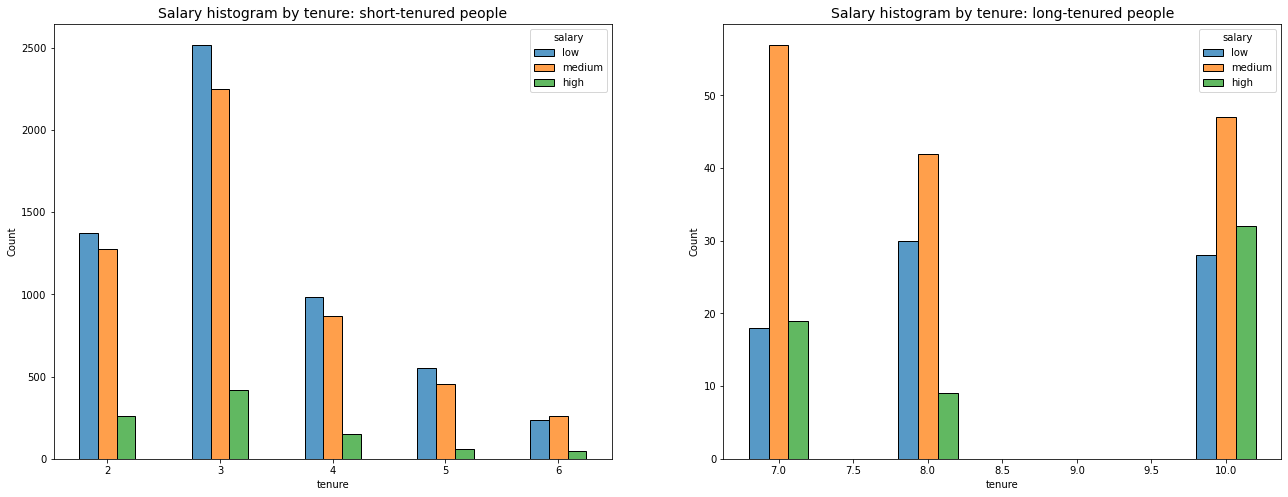

In [28]:
# Create a plot as needed
### YOUR CODE HERE ###
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df1[df1['tenure'] < 7]

# Define long-tenured employees
tenure_long = df1[df1['tenure'] > 6]

# Plot short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# Plot long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

In [29]:
# Create a plot as needed
### YOUR CODE HERE ###
df1["department"].value_counts()

sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: department, dtype: int64

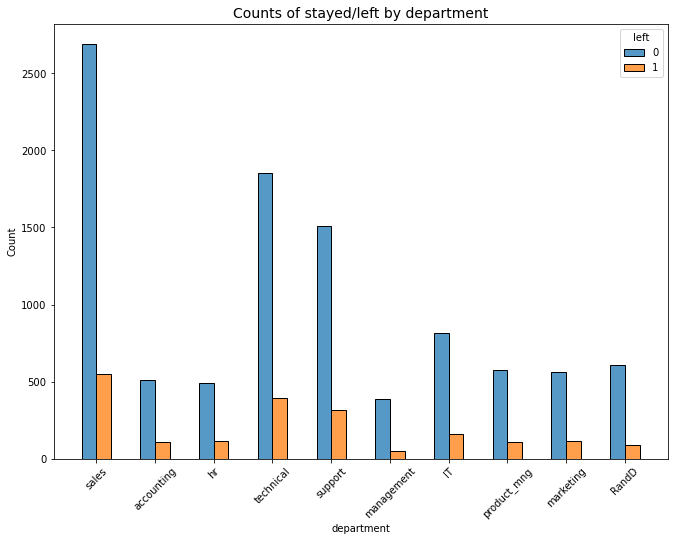

In [30]:
# Create a plot as needed
### YOUR CODE HERE ###
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation='45')
plt.title('Counts of stayed/left by department', fontsize=14);


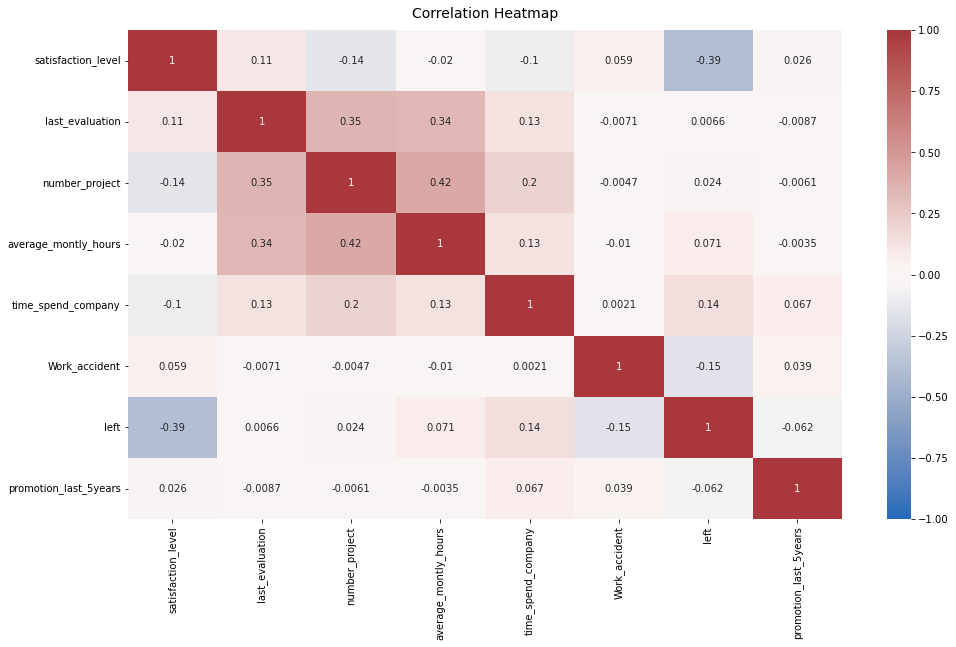

In [31]:
# Create a plot as needed
### YOUR CODE HERE ###
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

### Insights

It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. 

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This project seeks is to predict whether an employee leaves the company. ir. classify the employees into those who leave and those who stay. This is best solved using a binary classification, since the outcome variable `left` can be either 1 (indicating employee left) or 0 (indicating employee didn't leave). 

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

### Modeling

Add as many cells as you need to conduct the modeling process.

In [32]:
### YOUR CODE HERE ###
# Since salary and Department are categorical, we convert them into numerical form using one hot encoding
#Copy the dataframe
df_enc = df1.copy()

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Display the new dataframe
df_enc.head()


,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


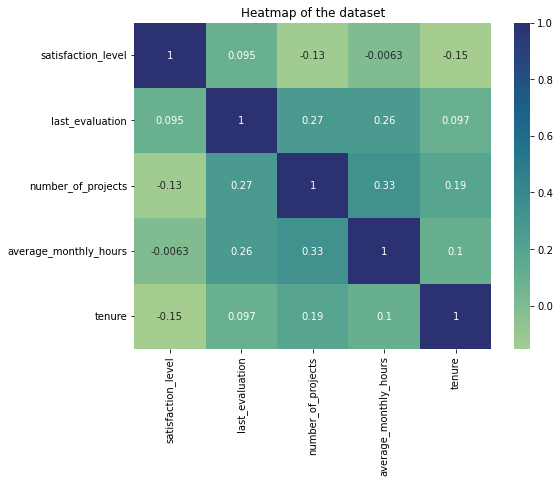

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_of_projects', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

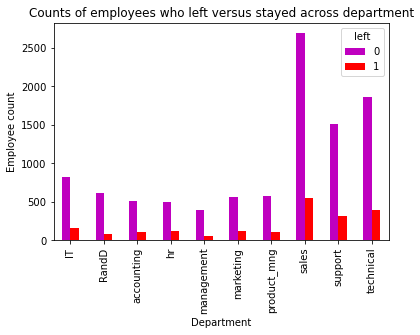

In [34]:
# Create a stacked bart plot to visualize number of employees across department, comparing those who left with those who didn't
# In the legend, 0 (purple color) represents employees who did not leave, 1 (red color) represents employees who left
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

In [35]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >= Q1) & (df_enc['tenure'] <= Q3)]

# Display first few rows of new dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
6,0.10,0.77,6,247,4,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [36]:
# Isolate the outcome variable
y = df_logreg['left']

# Display first few rows of the outcome variable
y.head()

0    1
2    1
4    1
5    1
6    1
Name: left, dtype: int64

In [37]:
 # Select the features you want to use in your model
X = df_logreg.drop('left', axis=1)

# Display the first few rows of the selected features 
X.head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0.10,0.77,6,247,4,0,0,0,0,0,0,0,0,0,0,1,0,0


In [38]:
# split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,
                                                    random_state = 42, stratify=y)

In [39]:
lr_model = LogisticRegression(max_iter = 1000, random_state = 42)

In [40]:
#fit model to training data 

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
#make predictions based on testing data 

y_pred = lr_model.predict(X_test)

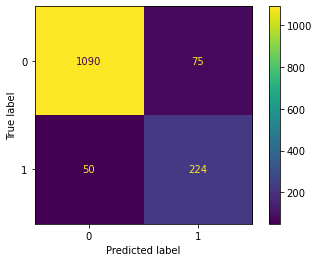

In [42]:
# Compute values for confusion matrix
# Compute values for confusion matrix
model_cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)

# Create display of confusion matrix
model_disp = ConfusionMatrixDisplay(confusion_matrix=model_cm, 
                                  display_labels=lr_model.classes_)

# Plot confusion matrix
model_disp.plot(values_format='')

# Display plot
plt.show()

In [43]:
df_logreg['left'].value_counts(normalize=True)

0    0.809729
1    0.190271
Name: left, dtype: float64

In [44]:
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.96      0.94      0.95      1165
    Predicted would leave       0.75      0.82      0.78       274

                 accuracy                           0.91      1439
                macro avg       0.85      0.88      0.86      1439
             weighted avg       0.92      0.91      0.91      1439



- **Predicted would not leave (Negative Class):**
  - Precision: 0.96 (This indicates the model's accuracy in predicting that a customer will not leave a tip, out of all the instances it predicted as such.)
  - Recall: 0.94 (This shows how well the model identified all the actual instances of customers who did not leave a tip.)
  - F1-score: 0.95 (The harmonic mean of precision and recall, giving a balance between the two metrics.)
  - Support: 1165 (The number of instances in the dataset for this class.)

- **Predicted would leave (Positive Class):**
  - Precision: 0.75 (This indicates how accurate the model was in predicting that a customer would leave a tip, out of all the instances it predicted as such.)
  - Recall: 0.82 (The model identified 82% of the actual instances where a customer left a tip.)
  - F1-score: 0.78 (The balance between precision and recall for the positive class.)
  - Support: 274 (The number of instances in the dataset for this class.)

- **Overall:**
  - Accuracy: 0.91 (The overall accuracy of the model, meaning it correctly predicted 91% of the instances.)
  - Macro Average: Precision 0.85, Recall 0.88, F1-score 0.86 (These values average the metrics across both classes, treating each class equally.)
  - Weighted Average: Precision 0.92, Recall 0.91, F1-score 0.91 (These values are weighted by the number of instances in each class, making them more reflective of the class distribution.)

It seems like the model is performing well, especially for the "would not leave" class. The recall and precision for the "would leave" class could be improved, which would boost the overall performance.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



**Logistic Regression**

The logistic regression model achieved precision of 92%, recall of 91%, f1-score of 91% (all weighted averages), and accuracy of 91%, on the test set.


## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Conclusion, Recommendations, Next Steps

the following recommendations could be presented to the stakeholders:
1. Limit the number of projects that employees can work on.
2. Consider promoting employees who have been with the company for atleast four years
3. Overtime bonuses for employees for working longer hours.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.